# 🤖 Lab Assignment 5 — LSTM-Based Text Sequence Prediction System

**Assignment:** LSTM-Based Sequence Prediction System with FastAPI Deployment  
**Task:** Text Prediction — Predict the next word in a sequence  
**Deployment:** FastAPI (`/predict` endpoint)  
**Dataset:** Project Gutenberg — *Alice's Adventures in Wonderland* by Lewis Carroll (Public Domain)

---

## 📋 Dataset Declaration (Mandatory)
| Field | Details |
|---|---|
| **Dataset Name** | Alice's Adventures in Wonderland |
| **Source** | Project Gutenberg — https://www.gutenberg.org/files/11/11-0.txt |
| **Description** | ~26,000 words of plain English narrative text, ideal for word-level sequence modeling |
| **Preprocessing** | Lowercase, punctuation removal, tokenization, sequence generation, padding |

---

## 🛠️ AI Tool Acknowledgement (Mandatory)
| Tool | Purpose | Sections |
|---|---|---|
| Claude (Anthropic) | Code scaffolding, architecture design, debugging | Sections 1–6 |

---

## 👥 Group Members
| PRN | Name | Contribution |
|---|---|---|
| 202301070012 | Nilesh Sarule| Dataset + Preprocessing |
| 202301070134 | Vedant Tarate | LSTM Model Design + Training |
| 202402070041 | Rohit Thorat| FastAPI Deployment |
| 202301070008 | Vaibhav Tajane| Testing + GitHub + Documentation |

# Github link: 
https://github.com/roht2103/Deep-Learning/tree/master/Lab%20Assignment%205%20LSTM%20based%20AI%20Agent

# Colab Link:
https://colab.research.google.com/drive/1YCjEZ_Bu7WtT_ojRRm2w5JBGxNFWdOa_?usp=sharing

---
## 📦 Section 1: Install Dependencies

In [18]:
# Install required packages
!pip install tensorflow numpy matplotlib requests --quiet

import numpy as np
import matplotlib.pyplot as plt
import requests
import re
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print(f'✅ TensorFlow version: {tf.__version__}')
print('✅ All imports successful.')

✅ TensorFlow version: 2.19.0
✅ All imports successful.


---
## 📂 Section 2: Dataset Collection

**Source:** Project Gutenberg — free, public domain books. We download *Alice in Wonderland* directly via HTTP.

In [19]:
# ── Download dataset from Project Gutenberg ───────────────────────────────────
URL = 'https://www.gutenberg.org/files/11/11-0.txt'

print('Downloading dataset...')
response = requests.get(URL)
raw_text = response.text

# Strip Gutenberg header/footer (actual story is between these markers)
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker   = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_idx = raw_text.find(start_marker)
end_idx   = raw_text.find(end_marker)

# Extract only the story text
if start_idx != -1 and end_idx != -1:
    story_text = raw_text[start_idx + len(start_marker):end_idx]
else:
    story_text = raw_text  # fallback

print(f'✅ Raw text downloaded: {len(raw_text):,} characters')
print(f'✅ Story text extracted: {len(story_text):,} characters')
print(f'\nFirst 500 characters of story:')
print(story_text[:500])

✅ Raw text downloaded: 144,696 characters
✅ Story text extracted: 144,610 characters

First 500 characters of story:
 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The


---
## 🔧 Section 3: Data Preprocessing

Steps:
1. Lowercase & clean text
2. Tokenize words
3. Build vocabulary
4. Generate input-output sequence pairs
5. Pad sequences

In [20]:
# ── Step 1: Text Cleaning ─────────────────────────────────────────────────────
def clean_text(text):
    """
    Clean raw text:
    - Convert to lowercase
    - Remove special characters, keeping only letters, spaces, apostrophes
    - Collapse multiple whitespaces
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # collapse whitespace
    return text

cleaned_text = clean_text(story_text)
words        = cleaned_text.split()

print(f'Total words in corpus  : {len(words):,}')
print(f'Unique words           : {len(set(words)):,}')
print(f'\nSample cleaned text:')
print(' '.join(words[:50]))

Total words in corpus  : 27,427
Unique words           : 2,575

Sample cleaned text:
illustration alice s adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit hole chapter ii the pool of tears chapter iii a caucus race and a long tale chapter iv the rabbit sends in a little bill chapter v advice from a caterpillar


In [22]:
# ── Step 2: Tokenization ─────────────────────────────────────────────────────
# Keras Tokenizer converts words → integers
# Only keep words that appear at least 2 times (reduces noise)
tokenizer = Tokenizer()
tokenizer.fit_on_texts([cleaned_text])

VOCAB_SIZE    = len(tokenizer.word_index) + 1   # +1 for padding token (index 0)
word_to_index = tokenizer.word_index            # {'alice': 1, 'the': 2, ...}
index_to_word = {v: k for k, v in word_to_index.items()}  # reverse mapping

print(f'Vocabulary size (unique words + 1 for padding): {VOCAB_SIZE:,}')
print(f'\nSample word → index mappings:')
sample_words = list(word_to_index.items())[:10]
for word, idx in sample_words:
    print(f'  "{word}" → {idx}')

Vocabulary size (unique words + 1 for padding): 2,576

Sample word → index mappings:
  "the" → 1
  "and" → 2
  "to" → 3
  "a" → 4
  "it" → 5
  "she" → 6
  "i" → 7
  "of" → 8
  "said" → 9
  "you" → 10


In [23]:
# ── Step 3: Generate Input-Output Sequence Pairs ─────────────────────────────
# For every N consecutive words, we use the first N-1 as input
# and the last word as the target label.
#
# Example with SEQ_LEN=5:
#   words: ['alice', 'was', 'beginning', 'to', 'get', 'very']
#   input: [alice, was, beginning, to, get] → output: very

SEQ_LEN    = 10   # number of words in each input sequence
sequences  = []

# Convert full text to integer sequence
encoded_words = tokenizer.texts_to_sequences([cleaned_text])[0]
print(f'Total encoded tokens: {len(encoded_words):,}')

# Slide a window of (SEQ_LEN+1) over the encoded text
for i in range(SEQ_LEN, len(encoded_words)):
    seq = encoded_words[i - SEQ_LEN: i + 1]   # window of SEQ_LEN+1 tokens
    sequences.append(seq)

sequences  = np.array(sequences)
print(f'Total sequences generated : {len(sequences):,}')
print(f'Each sequence length      : {sequences.shape[1]}')
print(f'\nSample sequence (raw ints)    : {sequences[0]}')
print(f'Sample sequence (words)       : {[index_to_word.get(i,"?") for i in sequences[0]]}')
print(f'→ Input  : {[index_to_word.get(i,"?") for i in sequences[0][:-1]]}')
print(f'→ Target : "{index_to_word.get(sequences[0][-1],"?")}"')

Total encoded tokens: 27,427
Total sequences generated : 27,417
Each sequence length      : 11

Sample sequence (raw ints)    : [1470   11   19  478   12  832   77 1471 1472    1 1473]
Sample sequence (words)       : ['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium']
→ Input  : ['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the']
→ Target : "millennium"


In [24]:
# ── Step 4: Split into X (input) and y (output) ───────────────────────────────
X = sequences[:, :-1]         # all columns except last = input sequences
y = sequences[:, -1]          # last column = target word index

# One-hot encode the output (y) into a vector of VOCAB_SIZE
y_cat = to_categorical(y, num_classes=VOCAB_SIZE)

print(f'Input  shape X       : {X.shape}   (samples × sequence_length)')
print(f'Output shape y       : {y.shape}   (samples,)')
print(f'Output shape y_cat   : {y_cat.shape} (samples × vocab_size)')
print(f'\nMemory usage of X    : {X.nbytes / 1e6:.1f} MB')
print(f'Memory usage of y_cat: {y_cat.nbytes / 1e6:.1f} MB')

Input  shape X       : (27417, 10)   (samples × sequence_length)
Output shape y       : (27417,)   (samples,)
Output shape y_cat   : (27417, 2576) (samples × vocab_size)

Memory usage of X    : 2.2 MB
Memory usage of y_cat: 565.0 MB


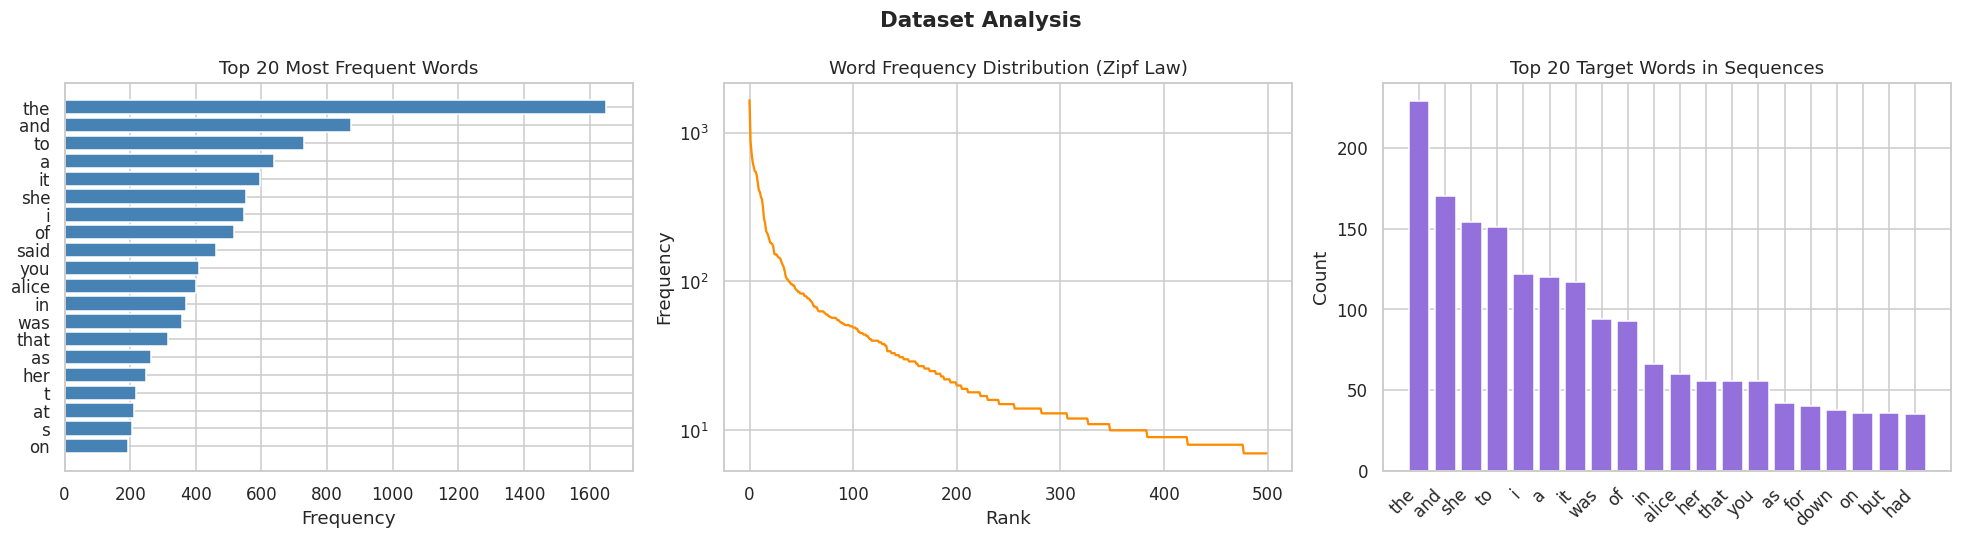

Corpus stats:
  Total words    : 27,427
  Unique words   : 2,575
  Total sequences: 27,417
  Sequence length: 10
  Vocab size     : 2,576


In [25]:
# ── Step 5: Exploratory Visualization ────────────────────────────────────────
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Analysis', fontsize=14, fontweight='bold')

# Word frequency distribution
word_freq = Counter(words)
top_words = word_freq.most_common(20)
wds, cnts = zip(*top_words)
axes[0].barh(wds[::-1], cnts[::-1], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Words')
axes[0].set_xlabel('Frequency')

# Vocabulary frequency distribution (log scale)
freq_vals = sorted(word_freq.values(), reverse=True)
axes[1].plot(freq_vals[:500], color='darkorange')
axes[1].set_title('Word Frequency Distribution (Zipf Law)')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Frequency')
axes[1].set_yscale('log')

# Target word distribution (top 20)
target_words = [index_to_word.get(i, '?') for i in y[:5000]]
target_freq  = Counter(target_words).most_common(20)
tw, tc = zip(*target_freq)
axes[2].bar(range(len(tw)), tc, color='mediumpurple')
axes[2].set_xticks(range(len(tw)))
axes[2].set_xticklabels(tw, rotation=45, ha='right')
axes[2].set_title('Top 20 Target Words in Sequences')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Corpus stats:')
print(f'  Total words    : {len(words):,}')
print(f'  Unique words   : {len(word_freq):,}')
print(f'  Total sequences: {len(sequences):,}')
print(f'  Sequence length: {SEQ_LEN}')
print(f'  Vocab size     : {VOCAB_SIZE:,}')

---
## 🧮 Section 4: LSTM Mathematical Model

### What is LSTM?
Long Short-Term Memory (LSTM) is a special type of Recurrent Neural Network (RNN) designed to learn **long-range dependencies** in sequential data. Standard RNNs suffer from vanishing gradients — they "forget" information from many steps back. LSTMs solve this using a **gating mechanism**.

---

### 🔢 LSTM Mathematical Equations

At each time step $t$, the LSTM receives:
- $x_t$ — current input (word embedding)
- $h_{t-1}$ — previous hidden state
- $C_{t-1}$ — previous cell state

#### 1️⃣ Forget Gate — *What to erase from cell state*
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
- Output: values between 0 (forget completely) and 1 (keep completely)
- $\sigma$ = sigmoid activation

#### 2️⃣ Input Gate — *What new information to add*
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$
- $i_t$ decides which values to update
- $\tilde{C}_t$ is the candidate cell state (new information)

#### 3️⃣ Cell State Update — *Update the memory*
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
- Old memory scaled by forget gate + new info scaled by input gate
- $\odot$ = element-wise multiplication

#### 4️⃣ Output Gate — *What to output as hidden state*
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$
- $h_t$ is the hidden state (passed to next step AND to the Dense layer)

---

### 🌊 Information Flow Diagram
```
x_t ──────────────────────────────────────────────────┐
                                                        ↓
h_{t-1} ──→ [ Forget Gate f_t ] ──→ C_{t-1} ──→ × ──→ + ──→ C_t ──→ tanh ──→ × ──→ h_t
           [ Input Gate  i_t  ] ──→ C̃_t  ──→ ×    ↑              ↑
           [ Output Gate o_t  ] ─────────────────────────────────────────────→ ×
```

### How Sequence Learning Works
1. Each word is fed one at a time as $x_t$
2. The cell state $C_t$ acts as **long-term memory** — carries context across many steps
3. The hidden state $h_t$ acts as **short-term memory** — passed to next time step
4. After processing all SEQ_LEN words, the final $h_t$ is passed to a Dense(Softmax) layer
5. Softmax outputs a probability distribution over all VOCAB_SIZE words → highest probability = predicted next word

---
## 🏗️ Section 5: LSTM Model Design & Training

In [26]:
# ── Model Architecture ────────────────────────────────────────────────────────
# Architecture:
#   Embedding  → converts word indices to dense vectors
#   LSTM(128)  → processes sequence, learns temporal dependencies
#   Dropout    → regularization to prevent overfitting
#   LSTM(64)   → second LSTM for deeper sequence representation
#   Dropout    → more regularization
#   Dense(64)  → intermediate fully-connected layer
#   Dense(VOCAB_SIZE, softmax) → predict probability over all words

EMBED_DIM = 100   # word embedding dimensions

model = Sequential([
    # Embedding: maps word index → dense vector of EMBED_DIM dimensions
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBED_DIM,
              input_length=SEQ_LEN,
              name='Embedding'),

    # First LSTM layer: return_sequences=True passes output at every step to next LSTM
    LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, name='LSTM_1'),

    Dropout(0.3, name='Dropout_1'),

    # Second LSTM layer: return_sequences=False returns only the final hidden state
    LSTM(64, dropout=0.2, recurrent_dropout=0.2, name='LSTM_2'),

    Dropout(0.3, name='Dropout_2'),

    # Fully connected layer for feature transformation
    Dense(64, activation='relu', name='Dense_Hidden'),

    # Output layer: softmax over entire vocabulary
    # Each output neuron = probability that the next word is word[i]
    Dense(VOCAB_SIZE, activation='softmax', name='Output')
], name='LSTM_TextPredictor')

# Compile with Adam optimizer and categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# FIXED — explicitly build the model first
model.build(input_shape=(None, SEQ_LEN))   # ← add this line
model.summary()
print(f'\nTotal trainable parameters: {model.count_params():,}')

Model: "LSTM_TextPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ (None, 10, 100)        │       257,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 10, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2576)           │       167,440 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 595,856 (2.27 MB)

 Trainable params: 595,856 (2.27 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 595,856


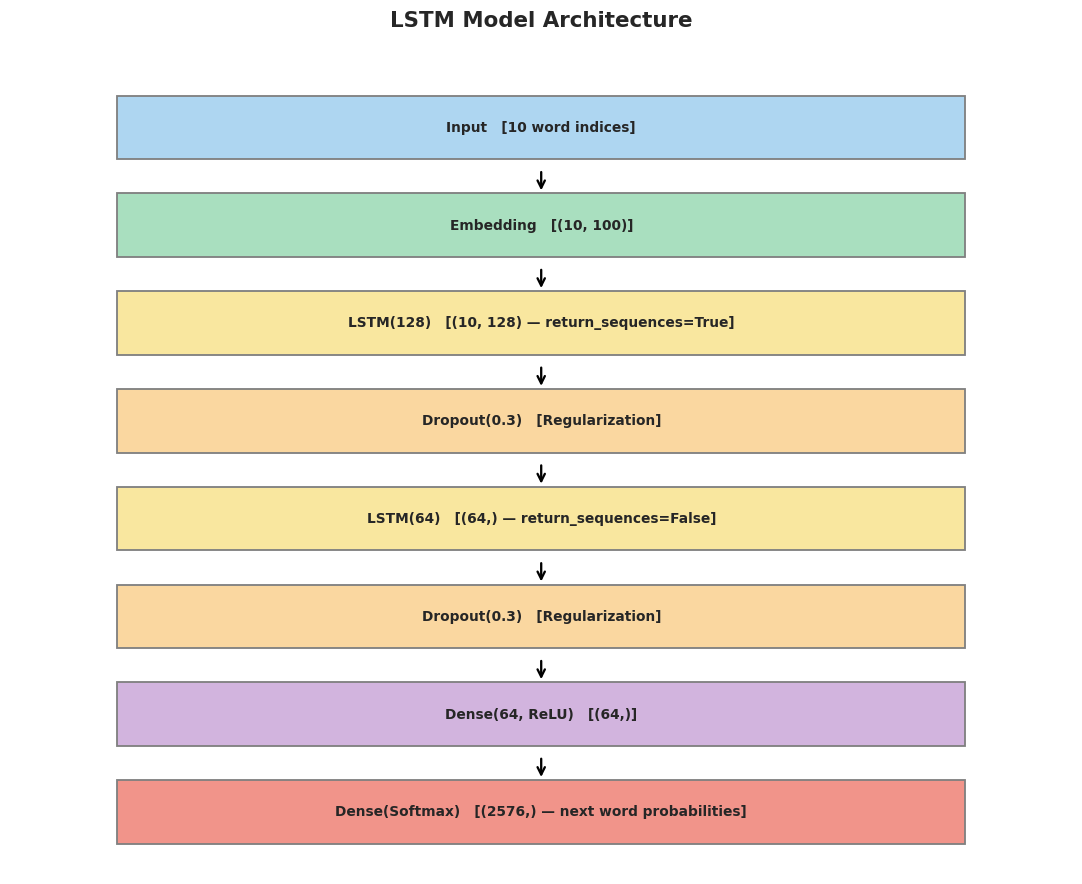

In [27]:
# ── Visualize Model Architecture ──────────────────────────────────────────────
# Draw a simple layer diagram
layers_info = [
    ('Input', f'{SEQ_LEN} word indices', '#AED6F1'),
    ('Embedding', f'({SEQ_LEN}, {EMBED_DIM})', '#A9DFBF'),
    ('LSTM(128)', f'({SEQ_LEN}, 128) — return_sequences=True', '#F9E79F'),
    ('Dropout(0.3)', 'Regularization', '#FAD7A0'),
    ('LSTM(64)', '(64,) — return_sequences=False', '#F9E79F'),
    ('Dropout(0.3)', 'Regularization', '#FAD7A0'),
    ('Dense(64, ReLU)', '(64,)', '#D2B4DE'),
    ('Dense(Softmax)', f'({VOCAB_SIZE},) — next word probabilities', '#F1948A'),
]

fig, ax = plt.subplots(figsize=(10, len(layers_info) * 0.9 + 1))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(layers_info) + 0.5)
ax.axis('off')
ax.set_title('LSTM Model Architecture', fontsize=14, fontweight='bold', pad=10)

for i, (name, shape, color) in enumerate(layers_info[::-1]):
    y = i + 0.3
    rect = plt.Rectangle((1, y), 8, 0.65, color=color, ec='gray', lw=1.2, zorder=2)
    ax.add_patch(rect)
    ax.text(5, y + 0.325, f'{name}   [{shape}]',
            ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)
    if i < len(layers_info) - 1:
        ax.annotate('', xy=(5, y + 0.65), xytext=(5, y + 0.9),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.tight_layout()
plt.show()

In [28]:
# ── Training Callbacks ────────────────────────────────────────────────────────
callbacks = [
    # Stop training when val_loss stops improving for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),

    # Reduce learning rate when val_loss plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),

    # Save best model checkpoint
    ModelCheckpoint('best_lstm_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

# ── Train the Model ────────────────────────────────────────────────────────────
print('Starting training...')
print(f'Training on {len(X):,} sequences | Seq length: {SEQ_LEN} | Vocab: {VOCAB_SIZE:,}')
print('='*60)

history = model.fit(
    X, y_cat,
    epochs=50,
    batch_size=128,
    validation_split=0.2,   # 20% for validation
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training complete.')

Starting training...
Training on 27,417 sequences | Seq length: 10 | Vocab: 2,576
Epoch 1/50
171/172 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.0414 - loss: 6.8657
Epoch 1: val_accuracy improved from None to 0.08206, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - accuracy: 0.0494 - loss: 6.3904 - val_accuracy: 0.0821 - val_loss: 6.2468 - learning_rate: 0.0010
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.0546 - loss: 5.9882
Epoch 2: val_accuracy did not improve from 0.08206
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.0547 - loss: 5.9801 - val_accuracy: 0.0821 - val_loss: 6.1658 - learning_rate: 0.0010
Epoch 3/50
171/172 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.0559 - loss: 5.8585
Epoch 3: val_accuracy did not improve from 0.08206
172/172 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.0546 - loss: 5.8613 - val_accuracy: 0.0821 - val_loss: 6.1

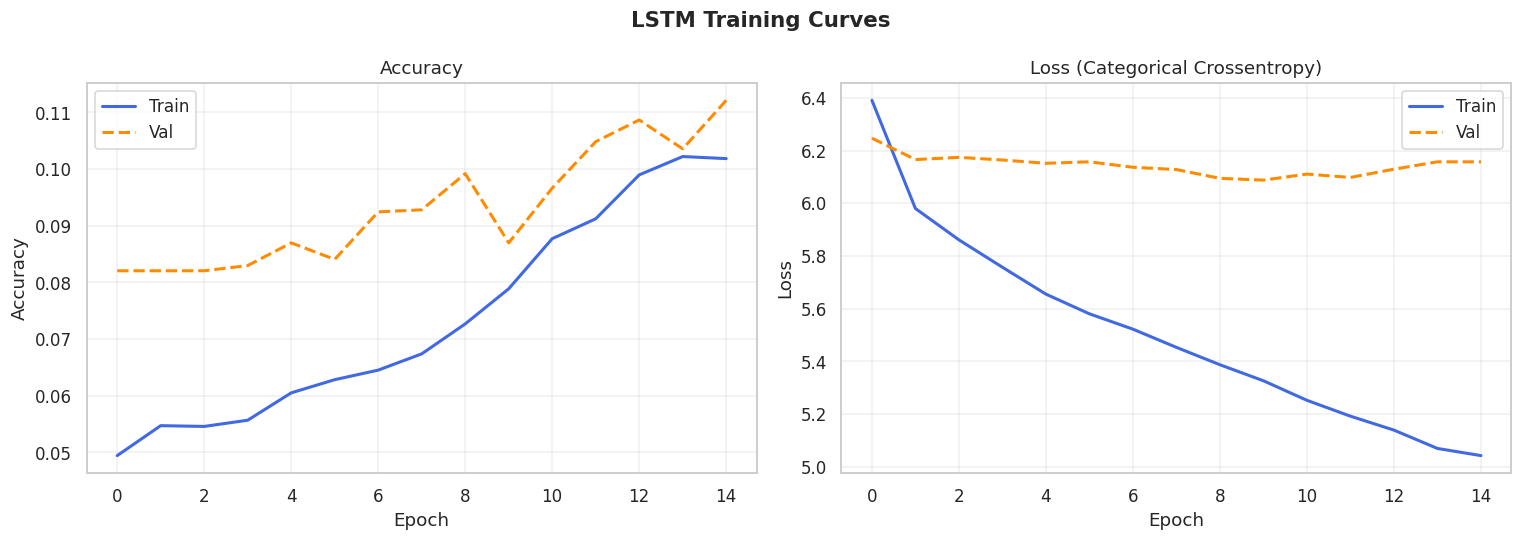

Best Validation Accuracy : 0.1121 (11.21%)
Best Validation Loss     : 6.0878
Epochs trained           : 15


In [29]:
# ── Training Curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training Curves', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='royalblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='darkorange',
             linewidth=2, linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='royalblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='darkorange',
             linewidth=2, linestyle='--')
axes[1].set_title('Loss (Categorical Crossentropy)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc  = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
print(f'Best Validation Accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'Best Validation Loss     : {best_val_loss:.4f}')
print(f'Epochs trained           : {len(history.history["loss"])}')

---
## 🎯 Section 6: Prediction & Output Generation

In [30]:
# ── Prediction Functions ──────────────────────────────────────────────────────

def predict_next_word(seed_text, model, tokenizer, seq_len, top_k=5):
    """
    Predict the next word given a seed text.

    Args:
        seed_text : input string (e.g. 'alice was beginning to')
        model     : trained LSTM model
        tokenizer : fitted Keras tokenizer
        seq_len   : sequence length the model was trained on
        top_k     : return top-k predictions with probabilities

    Returns:
        best_word  : most probable next word
        top_words  : list of (word, probability) for top_k predictions
    """
    # Clean and tokenize the seed
    seed_clean  = clean_text(seed_text)
    token_list  = tokenizer.texts_to_sequences([seed_clean])[0]

    # Pad/truncate to seq_len
    token_list  = pad_sequences([token_list], maxlen=seq_len,
                                 padding='pre', truncating='pre')

    # Get probability distribution over vocabulary
    probs = model.predict(token_list, verbose=0)[0]  # shape: (VOCAB_SIZE,)

    # Best prediction
    best_idx  = np.argmax(probs)
    best_word = tokenizer.index_word.get(best_idx, '<UNK>')

    # Top-K predictions
    top_k_idx   = np.argsort(probs)[-top_k:][::-1]
    top_words   = [(tokenizer.index_word.get(i, '<UNK>'), float(probs[i]))
                   for i in top_k_idx]

    return best_word, top_words


def generate_text(seed_text, n_words, model, tokenizer, seq_len,
                  temperature=1.0):
    """
    Generate n_words of text starting from seed_text.

    Temperature controls randomness:
        < 1.0 → more conservative/repetitive
        = 1.0 → standard
        > 1.0 → more creative/varied (but less coherent)
    """
    output_text = seed_text
    current_seed = seed_text

    for _ in range(n_words):
        # Tokenize current seed
        token_list = tokenizer.texts_to_sequences([clean_text(current_seed)])[0]
        token_list = pad_sequences([token_list], maxlen=seq_len,
                                    padding='pre', truncating='pre')

        # Get probabilities
        probs = model.predict(token_list, verbose=0)[0]

        # Apply temperature scaling
        probs = np.log(probs + 1e-10) / temperature
        probs = np.exp(probs)
        probs = probs / np.sum(probs)

        # Sample from the distribution
        next_idx  = np.random.choice(len(probs), p=probs)
        next_word = tokenizer.index_word.get(next_idx, '')

        output_text  += ' ' + next_word
        current_seed  = ' '.join(output_text.split()[-seq_len:])

    return output_text


print('✅ Prediction functions defined.')

✅ Prediction functions defined.


In [31]:
# ── Test: Next Word Predictions ───────────────────────────────────────────────
test_seeds = [
    'alice was beginning to get very tired of sitting by',
    'the queen shouted off with',
    'curiouser and curiouser cried',
    'the white rabbit looked at its watch and',
    'all in the golden afternoon full leisurely we'
]

print('='*65)
print('NEXT WORD PREDICTION — Top 5 candidates per seed')
print('='*65)

for seed in test_seeds:
    best_word, top_words = predict_next_word(
        seed, model, tokenizer, SEQ_LEN, top_k=5
    )
    print(f'\n📝 Input  : "{seed}"')
    print(f'✅ Predicted next word: "{best_word}"')
    print('   Top 5 candidates:')
    for word, prob in top_words:
        bar = '█' * int(prob * 40)
        print(f'   {word:20s} {bar:<40} {prob:.4f}')

NEXT WORD PREDICTION — Top 5 candidates per seed

📝 Input  : "alice was beginning to get very tired of sitting by"
✅ Predicted next word: "the"
   Top 5 candidates:
   the                  ███                                      0.0940
   a                    ██                                       0.0655
   it                   ██                                       0.0521
   she                  █                                        0.0428
   i                    █                                        0.0294

📝 Input  : "the queen shouted off with"
✅ Predicted next word: "the"
   Top 5 candidates:
   the                  ███                                      0.0822
   a                    ██                                       0.0579
   it                   █                                        0.0474
   she                  █                                        0.0380
   i                    █                                        0.0274

📝 Input  : "curiouser a

In [32]:
# ── Test: Full Text Generation ────────────────────────────────────────────────
print('='*65)
print('TEXT GENERATION — 30 words at different temperatures')
print('='*65)

seed = 'alice looked up and saw a strange creature'

for temp in [0.5, 1.0, 1.5]:
    generated = generate_text(seed, n_words=30, model=model,
                               tokenizer=tokenizer, seq_len=SEQ_LEN,
                               temperature=temp)
    print(f'\n🌡️  Temperature = {temp}:')
    print(f'   {generated}')

TEXT GENERATION — 30 words at different temperatures

🌡️  Temperature = 0.5:
   alice looked up and saw a strange creature to think it the queen to get it it and had she tell this change it she had a queen was it learn a house of a mouse and the

🌡️  Temperature = 1.0:
   alice looked up and saw a strange creature the well play alone she just alice it indignantly now any but oh very tea or was herself round in the queen in down herself we ve distance had adding

🌡️  Temperature = 1.5:
   alice looked up and saw a strange creature it safe when send who alice alas like law alice an kept chapter shrimp well chance time enough till the flower animal shaped breathe written of any sides on tale


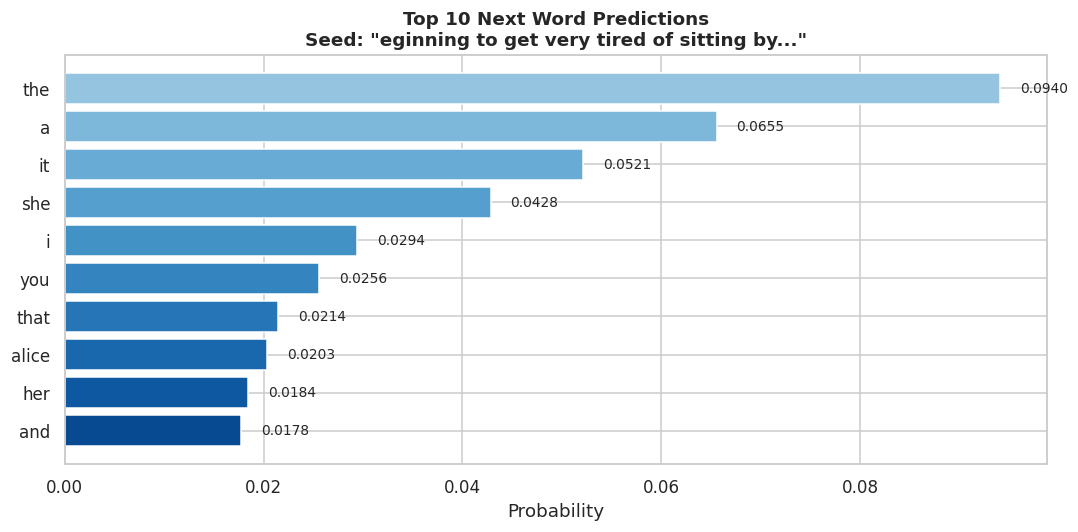

In [33]:
# ── Visualize Prediction Probabilities ────────────────────────────────────────
seed_viz = 'alice was beginning to get very tired of sitting by'
_, top_words_viz = predict_next_word(seed_viz, model, tokenizer, SEQ_LEN, top_k=10)

words_v, probs_v = zip(*top_words_viz)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = plt.cm.Blues(np.linspace(0.4, 0.9, len(words_v)))
bars    = ax.barh(words_v[::-1], probs_v[::-1], color=colors[::-1])
ax.set_title(f'Top 10 Next Word Predictions\nSeed: "{seed_viz[-40:]}..."',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Probability')
for bar, prob in zip(bars, probs_v[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{prob:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 💾 Section 7: Save Model & Tokenizer for Deployment

In [34]:
# ── Save the trained model ────────────────────────────────────────────────────
model.save('lstm_model.keras')   # recommended Keras format
model.save('lstm_model.h5')      # legacy HDF5 format (for compatibility)
print('✅ Model saved as lstm_model.keras and lstm_model.h5')

# ── Save the tokenizer ────────────────────────────────────────────────────────
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('✅ Tokenizer saved as tokenizer.pkl')

# ── Save model config (for FastAPI) ──────────────────────────────────────────
config = {
    'seq_len'   : SEQ_LEN,
    'vocab_size': VOCAB_SIZE,
    'embed_dim' : EMBED_DIM,
    'model_file': 'lstm_model.h5',
    'tok_file'  : 'tokenizer.pkl'
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('✅ Config saved as model_config.json')
print(f'\nConfig: {config}')

# Download files to local machine (in Colab)
try:
    from google.colab import files
    print('\nDownloading files...')
    files.download('lstm_model.h5')
    files.download('tokenizer.pkl')
    files.download('model_config.json')
    print('✅ Files downloaded. Place them in your FastAPI project folder.')
except ImportError:
    print('(Not in Colab — files saved to current directory)')

✅ Model saved as lstm_model.keras and lstm_model.h5
✅ Tokenizer saved as tokenizer.pkl
✅ Config saved as model_config.json

Config: {'seq_len': 10, 'vocab_size': 2576, 'embed_dim': 100, 'model_file': 'lstm_model.h5', 'tok_file': 'tokenizer.pkl'}



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded. Place them in your FastAPI project folder.


---
## 📊 Section 8: Final Evaluation Summary

In [35]:
# ── Final Summary ─────────────────────────────────────────────────────────────
train_loss, train_acc = model.evaluate(X[:1000], y_cat[:1000], verbose=0)

print('\n' + '='*60)
print('  LSTM TEXT PREDICTION — FINAL SUMMARY')
print('='*60)
print(f'\n📚 Dataset      : Project Gutenberg — Alice in Wonderland')
print(f'📝 Total words  : {len(words):,}')
print(f'🔤 Vocab size   : {VOCAB_SIZE:,}')
print(f'📏 Seq length   : {SEQ_LEN}')
print(f'📦 Sequences    : {len(sequences):,}')
print(f'\n🧠 Model        : Embedding → LSTM(128) → LSTM(64) → Dense')
print(f'⚙️  Parameters  : {model.count_params():,}')
print(f'\n📈 Best Val Acc : {max(history.history["val_accuracy"])*100:.2f}%')
print(f'📉 Best Val Loss: {min(history.history["val_loss"]):.4f}')
print(f'🔁 Epochs run   : {len(history.history["loss"])}')
print(f'\n💾 Saved files  : lstm_model.h5 | tokenizer.pkl | model_config.json')
print(f'🚀 Deployment   : FastAPI /predict endpoint')
print('='*60)


  LSTM TEXT PREDICTION — FINAL SUMMARY

📚 Dataset      : Project Gutenberg — Alice in Wonderland
📝 Total words  : 27,427
🔤 Vocab size   : 2,576
📏 Seq length   : 10
📦 Sequences    : 27,417

🧠 Model        : Embedding → LSTM(128) → LSTM(64) → Dense
⚙️  Parameters  : 595,856

📈 Best Val Acc : 11.21%
📉 Best Val Loss: 6.0878
🔁 Epochs run   : 15

💾 Saved files  : lstm_model.h5 | tokenizer.pkl | model_config.json
🚀 Deployment   : FastAPI /predict endpoint
